This project analyzes the historical performance of Apple Inc. (AAPL) over the past ten years. The goal is to explore long-term trends, volatility, and returns through a series of financial charts.

The dataset is sourced from Factset

I have calculated daily returns, examined volatility patterns, and applied technical indicators throughout this project. The result is structured analysis of how AAPL has behaved over the last decade.

I used Pandas for handling data, and matplotlib for data visualization

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize

df = pd.read_excel('PriceHistory.xlsx', header=2)

##df.head(5)

,Date,Price,CVol,Change,% Change,% Return,Total Return (Gross),Cumulative Return %,Open,High,Low,Cumulative Change %
0,2026-06-18,298.01,85962200.0,2.06,0.696064,0.696062,327.28522,1264.968074,298.110,300.57,295.62,1142.873527
1,2026-06-17,295.95,42745060.0,-3.29,-1.099452,-1.099441,325.02286,1255.532729,300.845,302.07,294.36,1134.282140
2,2026-06-16,299.24,39874400.0,2.82,0.951353,0.951342,328.63602,1270.601689,295.245,300.48,293.97,1148.003336
3,2026-06-15,296.42,45732566.0,5.29,1.817058,1.817065,325.53903,1257.685455,294.120,297.78,291.70,1136.242310
4,2026-06-12,291.13,38784793.0,-4.50,-1.522173,-1.522179,319.72934,1233.455698,296.030,297.14,289.62,1114.179960


Before the analysis, the data needed to be cleaned. This included renaming columns for easier use, renaming key fields,as well as converting the dates and sorting them.

In [26]:
## clean column names and rename
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('%', 'pct')
    .str.replace('.', '_')
)

df = df.rename(columns={
    'price': 'close',
    'cvol': 'volume'
})

## convert date column
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

###df[['date', 'open', 'high', 'low', 'close', 'volume']].head()


The closing price plot visualizes how Apple's closing price has changed over the last ten years. It provides a clear view of the long-term growth of the company, as well as major price movements.

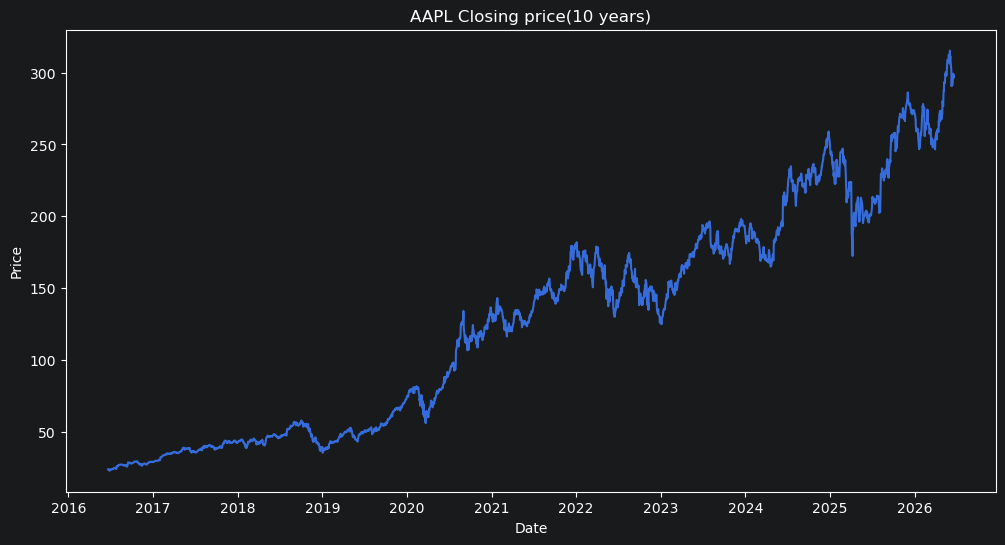

In [27]:
## plot closing price
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['close'])
plt.title('AAPL Closing price(10 years)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()






The daily return measure shows how much the stock price has changed from one day to the next. This demonstrates short term behavior and volatility. I calculated this using the percentage change in closing price.

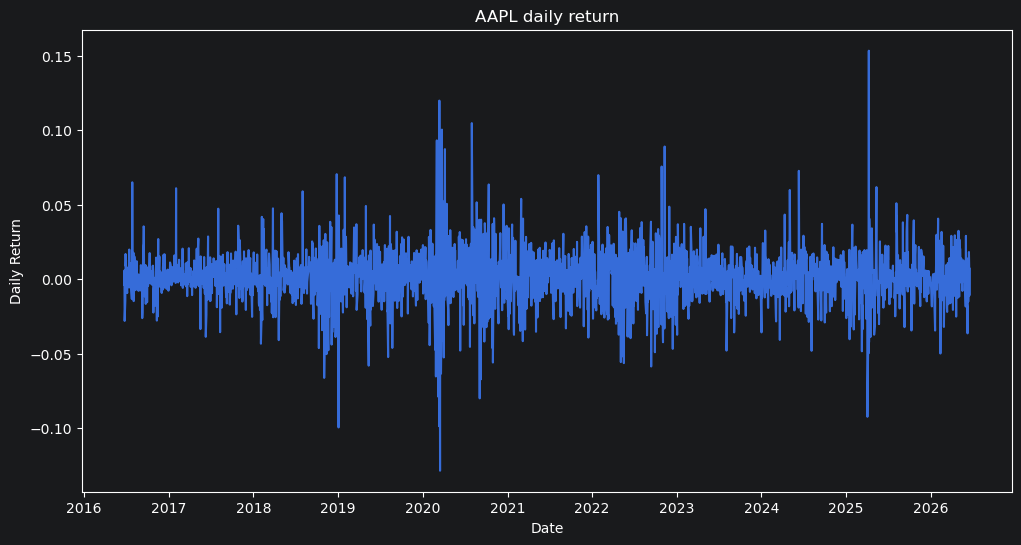

In [28]:
## Plot daily returns
df['daily_return'] = df['close'].pct_change()

plt.figure(figsize=(12,6))
plt.plot(df['date'], df['daily_return'])
plt.title('AAPL daily return')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.show()



The histogram reveals how often different daily returns occur. This helps visualize volatility, and whether returns tend to cluster around certain values.

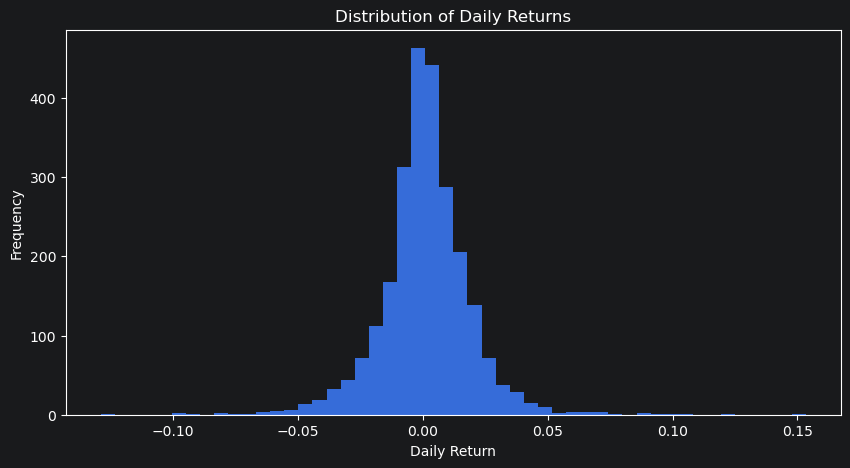

In [29]:
## histogram
plt.figure(figsize=(10,5))
plt.hist(df['daily_return'].dropna(), bins=50)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

Moving averages smooth out short‑term noise and highlight the overall trend. The 20‑, 50‑, and 200‑day averages show short‑, medium‑, and long‑term momentum.

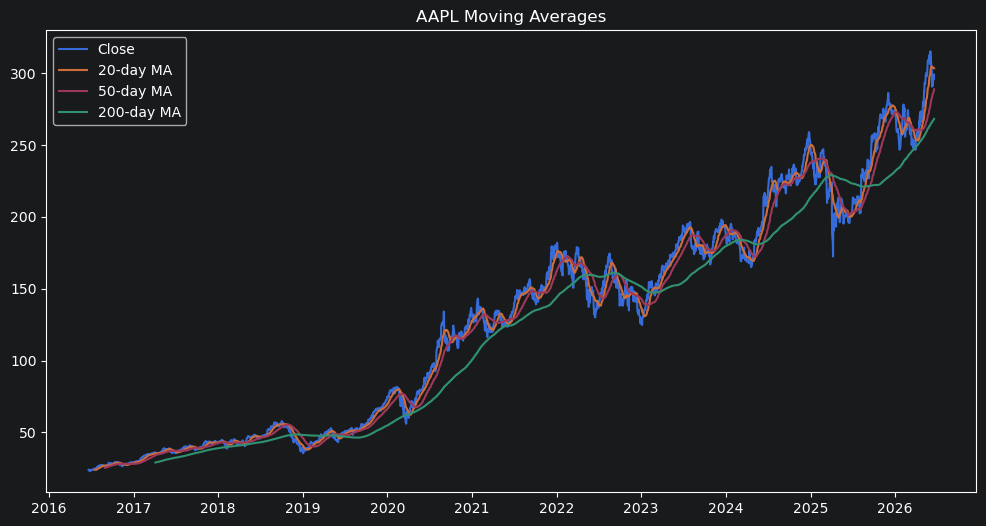

In [30]:
## Moving averages
df['ma20'] = df['close'].rolling(20).mean()
df['ma50'] = df['close'].rolling(50).mean()
df['ma200'] = df['close'].rolling(200).mean()

plt.figure(figsize=(12,6))
plt.plot(df['date'], df['close'], label='Close')
plt.plot(df['date'], df['ma20'], label='20-day MA')
plt.plot(df['date'], df['ma50'], label='50-day MA')
plt.plot(df['date'], df['ma200'], label='200-day MA')
plt.legend()
plt.title('AAPL Moving Averages')
plt.show()


Rolling volatility measures how much returns vary over time. Higher volatility indicates more risk and larger price swings.

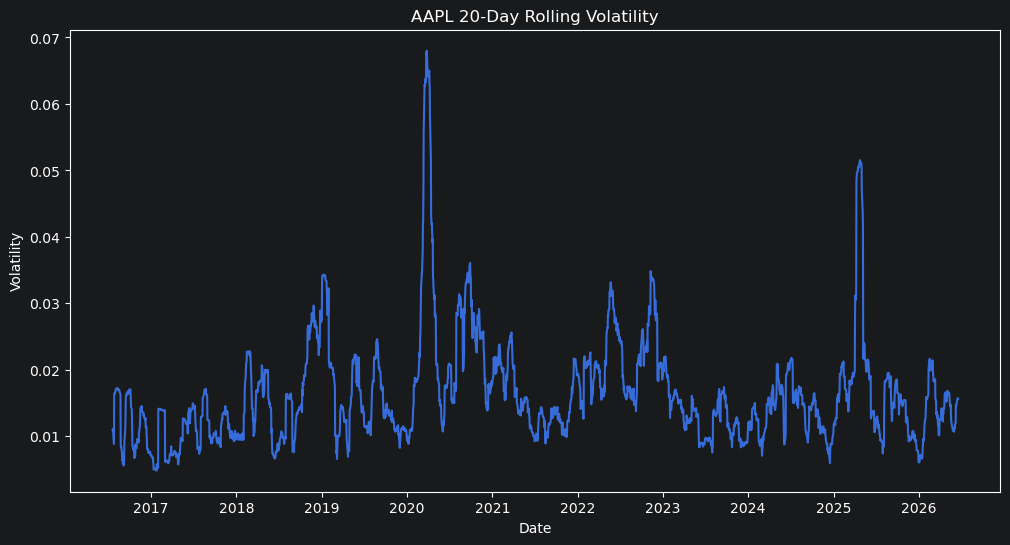

In [31]:
## rolling volatility
df['volatility_20'] = df['daily_return'].rolling(20).std()

plt.figure(figsize=(12,6))
plt.plot(df['date'], df['volatility_20'])
plt.title('AAPL 20-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()


Volume shows how actively the stock is being traded. Spikes in volume often align with news, earnings, or major price moves.

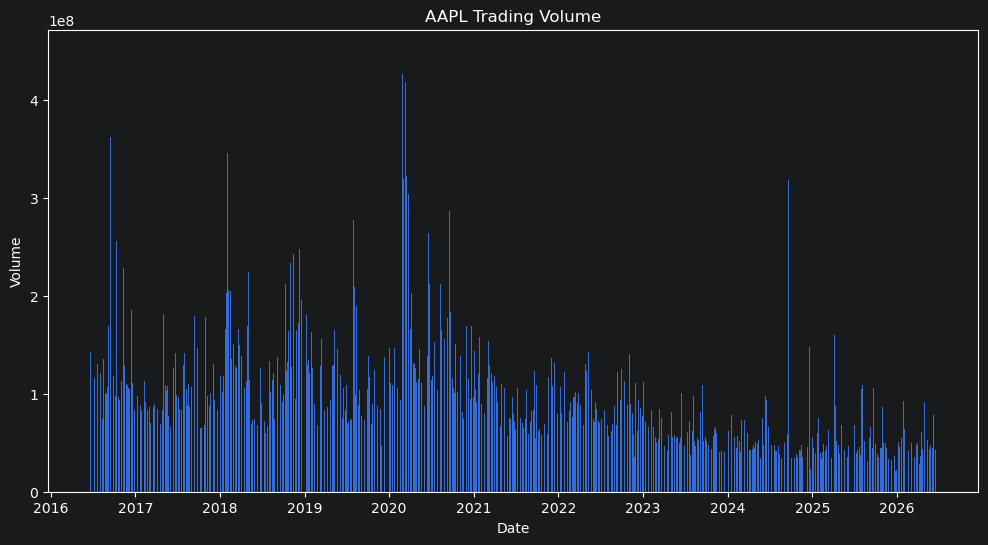

In [32]:
### Volume
plt.figure(figsize=(12,6))
plt.bar(df['date'], df['volume'])
plt.title('AAPL Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()


Cumulative return shows how much an initial investment would have grown over the full period. It highlights long‑term performance.

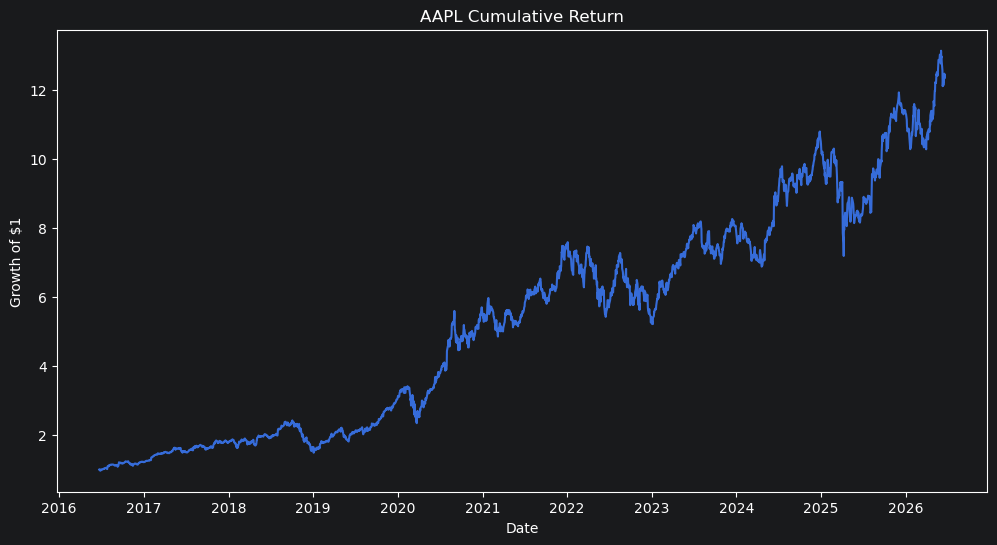

In [33]:
##Cumulative returns

df['cumulative_return'] = (1 + df['daily_return']).cumprod()

plt.figure(figsize=(12,6))
plt.plot(df['date'], df['cumulative_return'])
plt.title('AAPL Cumulative Return')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.show()


Overall, AAPL shows a long term upward trend with multiple periods of increased volatility. The moving averages confirm steady and consistent momentum, especially when the price stays above the 200 day line. Daily returns show occasional spikes, which often align with earnings announcements or broader market events. Volume tends to increase during major price moves, suggesting that investors react strongly during those periods. The cumulative return highlights significant long-term growth over the 10 year period.

This analysis gives a clear insight into Apple’s long‑term performance, short‑term volatility, and trading activity. The combination of price trends, returns, moving averages, and volume gives a clear picture of the stability and risk in AAPL's stock.
Future improvements could include comparing AAPL to a benchmark index, adding more technical indicators, or expanding the analysis into an interactive dashboard.